In [2]:
from datasets import load_dataset

ds = load_dataset("Sprakbanken/synthetic_sami_ocr_data")

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/20 [00:00<?, ?it/s]

In [3]:
print(ds) # hf dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'unique_id', 'text', 'text_line_id', 'raw_text', 'text_transform', 'font_path', 'font_size', 'text_color', 'background_color', 'top_margin', 'bottom_margin', 'left_margin', 'right_margin', 'bbox_left', 'bbox_top', 'bbox_right', 'bbox_bottom', 'image_width', 'image_height', 'undistorted_file_name', 'augraphy_log_path', 'distorted_bbox_left', 'distorted_bbox_top', 'distorted_bbox_right', 'distorted_bbox_bottom', 'language_code'],
        num_rows: 307387
    })
    validation: Dataset({
        features: ['image', 'unique_id', 'text', 'text_line_id', 'raw_text', 'text_transform', 'font_path', 'font_size', 'text_color', 'background_color', 'top_margin', 'bottom_margin', 'left_margin', 'right_margin', 'bbox_left', 'bbox_top', 'bbox_right', 'bbox_bottom', 'image_width', 'image_height', 'undistorted_file_name', 'augraphy_log_path', 'distorted_bbox_left', 'distorted_bbox_top', 'distorted_bbox_right', 'distorted_bbox_bottom', 'lang

In [4]:
train_data = ds['train']
test_data = ds['test']
validation_data = ds['validation']

In [5]:
train_data[0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=2290x156>,
 'unique_id': '000005e6-5430-4b8d-8fe0-398dfb181db3',
 'text': 'lii tavesämmilijn noonâ salmâveisidemärbivyehi,',
 'text_line_id': '26047872-ba09-448e-8f2d-23e7efb5097c',
 'raw_text': 'lii tavesämmilijn noonâ salmâveisidemärbivyehi,',
 'text_transform': 'identity',
 'font_path': 'Inter_Tight/static/InterTight-SemiBold.ttf',
 'font_size': 99,
 'text_color': '(62, 59, 44)',
 'background_color': '(190, 242, 255)',
 'top_margin': 50,
 'bottom_margin': 50,
 'left_margin': 100,
 'right_margin': 100,
 'bbox_left': 100,
 'bbox_top': 69,
 'bbox_right': 2220,
 'bbox_bottom': 167,
 'image_width': 2320,
 'image_height': 217,
 'undistorted_file_name': 'line_images/000005e6-5430-4b8d-8fe0-398dfb181db3.jpg',
 'augraphy_log_path': 'augraphy_logs/000005e6-5430-4b8d-8fe0-398dfb181db3.json',
 'distorted_bbox_left': 77.0,
 'distorted_bbox_top': 12.0,
 'distorted_bbox_right': 2197.0,
 'distorted_bbox_bottom': 110.0,
 'language_code

In [6]:
# get the image and text from the first element from the dataset
image = train_data[0]['image']
text = train_data[0]['text']

torch.Size([3, 156, 2290])
Image shape: torch.Size([3, 156, 2290])


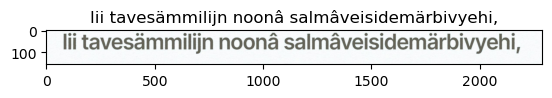

In [7]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# conversion pipeline - expandable
to_tensor = transforms.Compose([transforms.ToTensor()])

# transform the PIL image to tensor
tensor_img = to_tensor(image) # shape: (C, H, W), dtype=torch.float32
print(tensor_img.shape)       # torch.Size([3, 156, 2290])
print(f"Image shape: {tensor_img.shape}")

# permute the image to displayable format
img_np = tensor_img.permute(1,2,0).numpy() # (C, H, W) -> (H, W, C)

# display the image
plt.imshow(img_np)
plt.title(text)
plt.show()

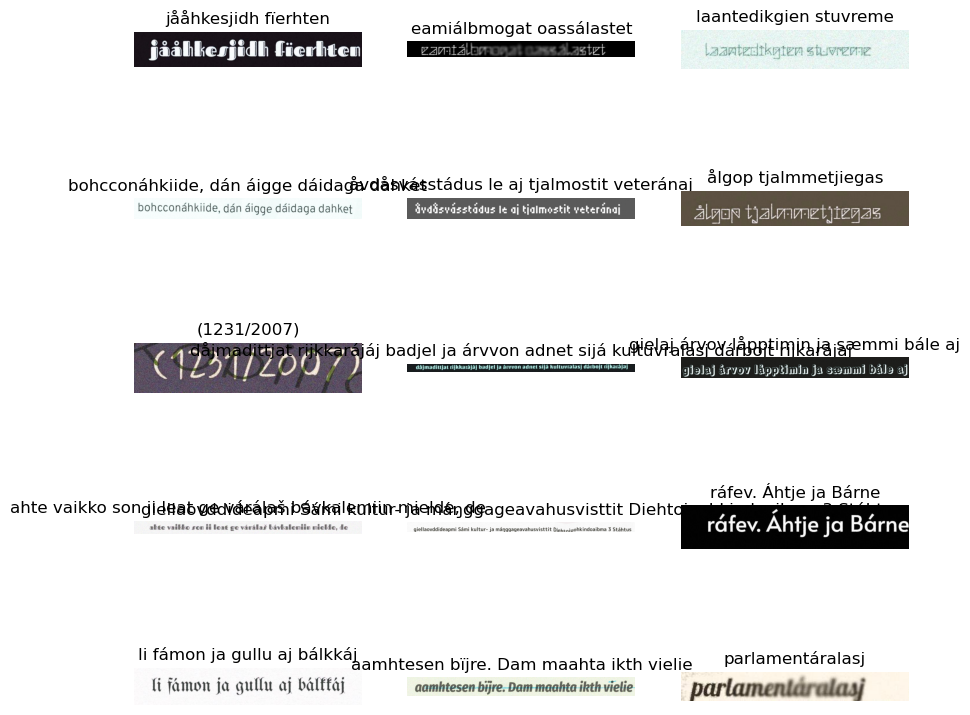

In [8]:
# plot more
torch.manual_seed(42)
fig = plt.figure(figsize=(10, 10))
rows, cols = 5, 3
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    image = train_data[random_idx]['image']
    label = train_data[random_idx]['text']

    tensor_img = transforms.ToTensor()(image).permute(1,2,0).numpy()

    fig.add_subplot(rows, cols, i)
    plt.imshow(tensor_img, cmap="gray")
    plt.title(label)
    plt.axis(False);

In [9]:
from collections import Counter
from wordcloud import WordCloud

import matplotlib.pyplot as plt

# Extract all text from training data
all_texts = [sample['text'] for sample in train_data]
combined_text = ' '.join(all_texts)

# 1. Most occurring words
words = combined_text.split()
word_counts = Counter(words)
print("Top 20 Most Occurring Words:")
for word, count in word_counts.most_common(20):
  print(f"  '{word}': {count}")

# 2. Most occurring letters
letters = [char for char in combined_text if char.isalpha()]
letter_counts = Counter(letters)
print("\nTop 20 Most Occurring Letters:")
for letter, count in letter_counts.most_common(20):
  print(f"  '{letter}': {count}")

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Word cloud for words
wordcloud_words = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)
axes[0].imshow(wordcloud_words, interpolation='bilinear')
axes[0].set_title('Word Cloud - Most Occurring Words', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Word cloud for letters
wordcloud_letters = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(letter_counts)
axes[1].imshow(wordcloud_letters, interpolation='bilinear')
axes[1].set_title('Word Cloud - Most Occurring Letters', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('./experiments/synth_data_analysis/word_letter_clouds.png', dpi=300, bbox_inches='tight')
plt.show()

# Bar charts for top 10
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 words
top_words = dict(word_counts.most_common(10))
axes[0].barh(list(top_words.keys()), list(top_words.values()), color='steelblue')
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 10 Most Occurring Words')
axes[0].invert_yaxis()

# Top 10 letters
top_letters = dict(letter_counts.most_common(10))
axes[1].barh(list(top_letters.keys()), list(top_letters.values()), color='coral')
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 10 Most Occurring Letters')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('./experiments/synth_data_analysis/top_words_letters_bars.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'train_data' is not defined

# Data Preparation

In [70]:
# Constants
BATCH_SIZE = 64 
IMAGE_SIZE = (32, 2048) # height, width
NUM_OF_CHANNELS = 1
TAKE_SIZE = 128 # for quick testing

### Charset and text encoding

In [74]:
# Build charset from your training data
def build_charset(dataset):
    """Extract all unique characters from the dataset"""
    chars = set()
    for sample in dataset:
        chars.update(sample['text'])
    chars.discard('') # remove empty character if present
    chars.discard(' ') # remove space if present, optional
    chars.discard('\n'); chars.discard('\t'); chars.discard('\r')
    # chars.discard('!')
    return sorted(list(chars))

# Build charset from training data
charset = build_charset(train_data.take(TAKE_SIZE)) # take first 1000 samples for charset
# char_to_idx = {char: idx for idx, char in enumerate(charset)}
# idx_to_char = {idx: char for char, idx in char_to_idx.items()}
# idx_to_char[0] = ''

char_to_idx = {c: i+1 for i,c in enumerate(charset)}
idx_to_char = {i+1: c for i,c in enumerate(charset)}

print(f"Charset size: {len(charset)}")
print(f"Charset: {''.join(charset)}")
print(f"char_to_idx: {char_to_idx}")

# Now use this for encoding text to indices
def encode_text(text, char_to_idx):
    """Convert text string to character indices"""
    return torch.tensor([char_to_idx[c] for c in text if c in char_to_idx], dtype=torch.long)

# Test it
test_text = "Dearvva"
encoded = encode_text(test_text, char_to_idx)
print(f"'{test_text}' encoded: {encoded}")

Charset size: 95
Charset: !"%'(),-./0123456789:;?ABCDEFGHIJKLMNOPRSTUVWZabcdefghijklmnoprstuvwyz|§ÁÂÄÅÏØáâäåæïöøČčĐđŠšž–“
char_to_idx: {'!': 1, '"': 2, '%': 3, "'": 4, '(': 5, ')': 6, ',': 7, '-': 8, '.': 9, '/': 10, '0': 11, '1': 12, '2': 13, '3': 14, '4': 15, '5': 16, '6': 17, '7': 18, '8': 19, '9': 20, ':': 21, ';': 22, '?': 23, 'A': 24, 'B': 25, 'C': 26, 'D': 27, 'E': 28, 'F': 29, 'G': 30, 'H': 31, 'I': 32, 'J': 33, 'K': 34, 'L': 35, 'M': 36, 'N': 37, 'O': 38, 'P': 39, 'R': 40, 'S': 41, 'T': 42, 'U': 43, 'V': 44, 'W': 45, 'Z': 46, 'a': 47, 'b': 48, 'c': 49, 'd': 50, 'e': 51, 'f': 52, 'g': 53, 'h': 54, 'i': 55, 'j': 56, 'k': 57, 'l': 58, 'm': 59, 'n': 60, 'o': 61, 'p': 62, 'r': 63, 's': 64, 't': 65, 'u': 66, 'v': 67, 'w': 68, 'y': 69, 'z': 70, '|': 71, '§': 72, 'Á': 73, 'Â': 74, 'Ä': 75, 'Å': 76, 'Ï': 77, 'Ø': 78, 'á': 79, 'â': 80, 'ä': 81, 'å': 82, 'æ': 83, 'ï': 84, 'ö': 85, 'ø': 86, 'Č': 87, 'č': 88, 'Đ': 89, 'đ': 90, 'Š': 91, 'š': 92, 'ž': 93, '–': 94, '“': 95}
'Dearvva' encoded:

In [82]:
# 1. Fix: Verify blank token index calculation
blank_idx = len(idx_to_char)  # Should be 95
nclass = len(charset) + 1     # Should be 96
print(f"Blank index: {blank_idx}, nclass: {nclass}")
has_exclamation = any('!' in sample['text'] for sample in train_data.take(1000))
print(f"'!' in training data: {has_exclamation}")
encode_text("test!", char_to_idx)

Blank index: 95, nclass: 96
'!' in training data: True


tensor([65, 51, 64, 65,  1])

### Build the dataset

In [83]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class SamiOCRDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform or transforms.Compose([
            transforms.Grayscale(num_output_channels=NUM_OF_CHANNELS), # convert to 1 channel for CRNN feature map
            transforms.Resize(IMAGE_SIZE), # resize to fixed height and variable width
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5]) # normalize to [-1, 1]
        ])
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        sample = self.dataset[idx]
        image = self.transform(sample['image'])
        # text = torch.t(sample['text'])

        # encode text to indices
        text = encode_text(sample['text'], char_to_idx)
        
        return image, text



# Create datasets
train_dataset = SamiOCRDataset(train_data.take(5000)) # take first 1000 samples for quick testing
test_dataset = SamiOCRDataset(test_data.take(1000))



## Dataloader

In [84]:
def collate_fn(batch):
    """
    Custom collate function for variable-length text sequences.
    Args:
        batch: list of (image, text) tuples from __getitem__
    
    Returns:
        images: stacked tensor (batch_size, 1, 256, 256)
        texts: concatenated tensor (total_chars,)
        text_lengths: tensor tracking each text length (batch_size,)
    """
    images = []
    texts = []
    text_lengths = []
    
    for image, text in batch:
        images.append(image)
        texts.append(text)
        text_lengths.append(len(text))
    
    # Stack images (all same size - no problem)
    images = torch.stack(images)
    
    # Concatenate texts into one flat tensor
    texts = torch.cat(texts)
    
    # Track original lengths for CTC Loss
    text_lengths = torch.tensor(text_lengths, dtype=torch.long)
    
    return images, texts, text_lengths

# Create dataloaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)


print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

# Test it
batch_images, batch_texts, batch_text_lengths = next(iter(train_dataloader))
print(f"Images shape: {batch_images.shape}")
print(f"Texts shape: {batch_texts.shape}")
print(f"Text lengths: {batch_text_lengths}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7fff144becf0>, <torch.utils.data.dataloader.DataLoader object at 0x7fff37c73a40>)
Length of train dataloader: 79 batches of 64
Length of test dataloader: 16 batches of 64
Images shape: torch.Size([64, 1, 32, 2048])
Texts shape: torch.Size([2308])
Text lengths: tensor([69, 51,  9, 49, 15,  8, 46, 59, 14, 41, 24, 15, 73, 40, 49, 38, 47, 49,
        30, 46, 23, 10, 67, 24, 15, 37, 45, 31, 29, 83, 22, 43, 42, 46, 18, 43,
        31, 20, 56, 39, 38, 48, 64, 26, 48, 34, 25, 65, 54, 40, 17, 18, 12, 32,
         5, 15, 22, 48,  9, 35, 54, 20, 70, 13])


# Baseline model

In [85]:
import torch
import torch.nn as nn
 
class CRNN(nn.Module):
    def __init__(self, imgH, nc, nclass, nh):
        super(CRNN, self).__init__()
        assert imgH % 16 == 0, 'imgH has to be a multiple of 16'
 
        # CNN part
        cnn = nn.Sequential()
        cnn.add_module('conv0', nn.Conv2d(nc, 64, 3, 1, 1))
        cnn.add_module('relu0', nn.ReLU(True))
        cnn.add_module('pool0', nn.MaxPool2d(2, 2))
 
        cnn.add_module('conv1', nn.Conv2d(64, 128, 3, 1, 1))
        cnn.add_module('relu1', nn.ReLU(True))
        cnn.add_module('pool1', nn.MaxPool2d(2, 2))
 
        cnn.add_module('conv2', nn.Conv2d(128, 256, 3, 1, 1))
        cnn.add_module('bn2', nn.BatchNorm2d(256))
        cnn.add_module('relu2', nn.ReLU(True))
 
        cnn.add_module('conv3', nn.Conv2d(256, 256, 3, 1, 1))
        cnn.add_module('relu3', nn.ReLU(True))
        cnn.add_module('pool3', nn.MaxPool2d((2, 2), (2, 1), (0, 1)))
 
        cnn.add_module('conv4', nn.Conv2d(256, 512, 3, 1, 1))
        cnn.add_module('bn4', nn.BatchNorm2d(512))
        cnn.add_module('relu4', nn.ReLU(True))
 
        cnn.add_module('conv5', nn.Conv2d(512, 512, 3, 1, 1))
        cnn.add_module('relu5', nn.ReLU(True))
        cnn.add_module('pool5', nn.MaxPool2d((2, 2), (2, 1), (0, 1)))
 
        cnn.add_module('conv6', nn.Conv2d(512, 512, 2, 1, 0))
        cnn.add_module('bn6', nn.BatchNorm2d(512))
        cnn.add_module('relu6', nn.ReLU(True))
        self.cnn = cnn
 
        # RNN part
        # self.rnn = nn.Sequential(
        self.lstm1 = nn.LSTM(512, nh, bidirectional=True, batch_first=False)
        self.lstm2 = nn.LSTM(nh * 2, nh, bidirectional=True, batch_first=False)
        # )

        self.dropout = nn.Dropout(0.3) # Add dropout for regularization
        
        # Transcription layer
        self.linear = nn.Linear(nh * 2, nclass)
 
    def forward(self, input):
        # CNN forward
        conv = self.cnn(input)
        b, c, h, w = conv.size()
        assert h == 1, "the height of conv must be 1"
        conv = conv.squeeze(2)
        conv = conv.permute(2, 0, 1)  # [w, b, c]
 
        # RNN forward
        recurrent, _ = self.lstm1(conv)
        recurrent, _ = self.lstm2(recurrent)

        T, b, h = recurrent.size()
        t_rec = recurrent.view(T * b, h)
        output = self.linear(t_rec)
        output = output.view(T, b, -1)
        return output

### Training (old)

In [86]:
# Initialize the model
# imgH - image height (multiple of 16, must match the image height of input images)
# nc - number of channels (1 for grayscale, 3 for RGB)
# nclass - number of output classes (characters + blank for CTC)

# model = CRNN(
#   imgH=IMAGE_SIZE[0],               # image height, must be a multiple of 16, and should match the height of the input images after transformations
#     nc=NUM_OF_CHANNELS,                 # number of input channels
#     nclass=len(charset),  # number of output classes (characters + blank for CTC), depends on the character set (alphabet + special chars)
#     nh=256    )           # number of hidden units in RNN (LSTM) layers


# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

# # Connectionist temporal classification (CTC) loss for sequence-to-sequence problems where alignment is unknown
# criterion = nn.CTCLoss()
# # Optimizer
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def training_loop1(model, train_dataloader, criterion, optimizer, EPOCHS):
  
  # Training loop
  for epoch in range(EPOCHS):
      batch_no = 0
      for batch_images, batch_texts, batch_text_lengths in train_dataloader:
        # print(f"Batch images shape: {batch_images.shape}")
        # print(f"Batch texts shape: {batch_texts.shape}")
        # print(f"Batch text lengths: {batch_text_lengths}")
        # Here you would need to convert batch_texts to target_tensor format suitable for CTC loss, and also compute input_lengths and target_lengths based on the actual data
        optimizer.zero_grad() # clear the gradients
        # forward pass - character probabilities for each position (get prediction)
        output = model(batch_images)
        # print(f"prediction {output.shape}") # [T, batch_size, nclass]

        T = output.size(0)
        batch_size = output.size(1)

        if T < (batch_text_lengths.max().item()):
            print(f"Warning: T={T} is less than max target length {batch_text_lengths.max().item()}. Skipping this batch.")
            continue

        input_lengths = torch.full(size=(batch_size,), fill_value=T, dtype=torch.long)


        loss = criterion(output.log_softmax(2), batch_texts, input_lengths, batch_text_lengths)
        loss.backward()
        optimizer.step()
        batch_no += 1
        # print(f"Batch {batch_no}, Loss: {loss.item()}")
      print(f'\n========================================================')
      print(f'Epoch {epoch+1}, Loss: {loss.item()}')
      print(f'========================================================\n')

### Improved training

In [87]:
from datetime import datetime

import torch
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
from pathlib import Path
import json
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.LSTM):
        for name, param in m.named_parameters():
            if 'weight' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0)

def train(model, device, train_dataloader, test_dataloader, criterion, optimizer, scheduler, EPOCHS, EARLY_STOPPING_PATIENCE, GRADIENT_CLIP_VALUE, checkpoint_dir):
  # Tracking metrics
  train_losses = []
  val_losses = []
  best_val_loss = float('inf')
  patience_counter = 0

  # Training loop
  for epoch in range(EPOCHS):
      print(f"\nEpoch {epoch+1}/{EPOCHS}")  
      # Training phase
      model.train()
      epoch_train_loss = 0.0
      batch_count = 0
      
      for batch_images, batch_texts, batch_text_lengths in train_dataloader:
          batch_images = batch_images.to(device)
          batch_texts = batch_texts.to(device)
          batch_text_lengths = batch_text_lengths.to(device)
          
          optimizer.zero_grad()
          
          output = model(batch_images)
          T, batch_size, _ = output.size()
          
          if T < batch_text_lengths.max().item():
              print(f"Warning: Skipping batch (T={T} < max_length={batch_text_lengths.max().item()})")
              continue
          
          input_lengths = torch.full((batch_size,), T, dtype=torch.long, device=device)
          
          loss = criterion(output.log_softmax(2), batch_texts, input_lengths, batch_text_lengths)
          
          loss.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_VALUE)
          optimizer.step()
          
          epoch_train_loss += loss.item()
          batch_count += 1
      
      avg_train_loss = epoch_train_loss / batch_count
      train_losses.append(avg_train_loss)
      
      # Validation phase
      model.eval()
      epoch_val_loss = 0.0
      val_batch_count = 0
      
      with torch.no_grad():
          for batch_images, batch_texts, batch_text_lengths in test_dataloader:
              batch_images = batch_images.to(device)
              batch_texts = batch_texts.to(device)
              batch_text_lengths = batch_text_lengths.to(device)
              
              output = model(batch_images)
              T, batch_size, _ = output.size()
              
              if T < batch_text_lengths.max().item():
                  continue
              
              input_lengths = torch.full((batch_size,), T, dtype=torch.long, device=device)
              loss = criterion(output.log_softmax(2), batch_texts, input_lengths, batch_text_lengths)
              
              epoch_val_loss += loss.item()
              val_batch_count += 1
      
      avg_val_loss = epoch_val_loss / val_batch_count
      val_losses.append(avg_val_loss)
      
      # Learning rate scheduling
      scheduler.step(avg_val_loss)
      
      print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')
      
      # Checkpointing
      if avg_val_loss < best_val_loss:
          best_val_loss = avg_val_loss
          patience_counter = 0
          
          checkpoint = {
              'epoch': epoch,
              'model_state_dict': model.state_dict(),
              'optimizer_state_dict': optimizer.state_dict(),
              'val_loss': avg_val_loss,
              'train_loss': avg_train_loss,
          }
          torch.save(checkpoint, checkpoint_dir / f'best_model{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.pt')
          print(f"✓ Checkpoint saved at epoch {epoch+1}")
      else:
          patience_counter += 1
          if patience_counter >= EARLY_STOPPING_PATIENCE:
              print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {EARLY_STOPPING_PATIENCE} epochs)")
              break

  print("Training complete!")

  # Plot training history
  fig, ax = plt.subplots(figsize=(10, 6))
  ax.plot(train_losses, label='Training Loss', linewidth=2)
  ax.plot(val_losses, label='Validation Loss', linewidth=2)
  ax.set_xlabel('Epoch')
  ax.set_ylabel('Loss (CTC)')
  ax.set_title('Training and Validation Loss Over Epochs')
  ax.legend()
  ax.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.savefig('./training_history.png', dpi=300)
  plt.show()

  print(f"Best validation loss: {best_val_loss:.4f}")

##### Run training

In [92]:
# Create checkpoint directory
checkpoint_dir = Path(f"./checkpoints/{datetime.now().strftime('%Y-%m-%d_%H-%M')}")
checkpoint_dir.mkdir(exist_ok=True)

# Initialize the model
model = CRNN(
    imgH=IMAGE_SIZE[0],
    nc=NUM_OF_CHANNELS,
    nclass=len(charset) + 1,  # +1 for CTC blank token
    nh=256 # Reduced from 256 for faster training
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CTCLoss(reduction='mean', zero_infinity=True)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)


model.apply(init_weights)

# 4. Fix: Lower learning rate and use better scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Reduced from 0.001
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=7, verbose=False)

EPOCHS = 200
EARLY_STOPPING_PATIENCE = 100 
GRADIENT_CLIP_VALUE = 1.0

# RUn training
train(model, device, train_dataloader, test_dataloader, criterion, optimizer, scheduler, EPOCHS, EARLY_STOPPING_PATIENCE, GRADIENT_CLIP_VALUE, checkpoint_dir)

/nix/store/q1pi2anj86bkfvx91nmd79m5saan4zi6-python3-3.12.4-env/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "



Epoch 1/200
Epoch 1/200 | Train Loss: 8.5961 | Val Loss: 4.0832
✓ Checkpoint saved at epoch 1

Epoch 2/200
Epoch 2/200 | Train Loss: 4.1923 | Val Loss: 4.1896

Epoch 3/200
Epoch 3/200 | Train Loss: 4.1279 | Val Loss: 4.2251

Epoch 4/200
Epoch 4/200 | Train Loss: 4.1694 | Val Loss: 4.4854

Epoch 5/200
Epoch 5/200 | Train Loss: 4.1437 | Val Loss: 4.2120

Epoch 6/200
Epoch 6/200 | Train Loss: 4.1455 | Val Loss: 4.0244
✓ Checkpoint saved at epoch 6

Epoch 7/200
Epoch 7/200 | Train Loss: 4.1941 | Val Loss: 3.9976
✓ Checkpoint saved at epoch 7

Epoch 8/200
Epoch 8/200 | Train Loss: 4.0542 | Val Loss: 4.0784

Epoch 9/200
Epoch 9/200 | Train Loss: 4.1024 | Val Loss: 4.0307

Epoch 10/200
Epoch 10/200 | Train Loss: 4.0353 | Val Loss: 4.0133

Epoch 11/200
Epoch 11/200 | Train Loss: 4.0912 | Val Loss: 3.9497
✓ Checkpoint saved at epoch 11

Epoch 12/200
Epoch 12/200 | Train Loss: 4.0323 | Val Loss: 3.9701

Epoch 13/200
Epoch 13/200 | Train Loss: 4.0842 | Val Loss: 4.0793

Epoch 14/200
Epoch 14/200

KeyboardInterrupt: 

### Validation

In [ ]:
def decode_predictions(output, idx_to_char):
    preds = output.argmax(2).permute(1,0)         # [batch, T]
    decoded = []
    for seq in preds:
        prev = None
        out = []
        for idx in seq.tolist():
            if idx == blank_idx or idx == prev:    # skip blanks & repeats
                prev = idx
                continue
            out.append(idx_to_char.get(idx, ''))
            prev = idx
        decoded.append(''.join(out))
    return decoded

def ground_truth_from_batch(batch_texts, batch_text_lengths, idx_to_char):
    """Convert flattened ground truth back to text strings."""
    texts = []
    start = 0
    for length in batch_text_lengths:
        length = length.item()
        text_indices = batch_texts[start:start+length]
        text = ''.join([idx_to_char.get(idx.item(), '?') for idx in text_indices])
        texts.append(text)
        start += length
    return texts


# Validation loop
model.eval()
total_correct = 0
total_samples = 0
all_predictions = []
all_ground_truth = []

# 5. Debug: Check CNN output shape
test_batch = next(iter(train_dataloader))
with torch.no_grad():
    images = test_batch[0].to(device)
    # print(f"Input shape: {images.shape}")
    
    # Trace through CNN
    conv = model.cnn(images)
    # print(f"CNN output shape: {conv.shape}")
    # print(f"Expected height: 1, Got: {conv.size(2)}")

with torch.no_grad():
    for batch_images, batch_texts, batch_text_lengths in test_dataloader:
        batch_images = batch_images.to(device)
        batch_texts = batch_texts.to(device)
        batch_text_lengths = batch_text_lengths.to(device)
        
        output = model(batch_images)
        T, batch_size, _ = output.size()
        
        if T < batch_text_lengths.max().item():
            continue           

        # Check raw logits
        raw_predictions = output.argmax(2)  # [T, batch_size]
        # print(f"Raw prediction shape: {raw_predictions.shape}")
        # print(f"Unique indices predicted: {torch.unique(raw_predictions).tolist()}")
        # print(f"Blank index: {len(idx_to_char)}")
        # print(f"First batch predictions (first 50 timesteps):")
        # print(raw_predictions[:50, 0].tolist())
        
        # Check logit values
        # print(f"\nLogit ranges:")
        # print(f"Min: {output.min():.4f}, Max: {output.max():.4f}, Mean: {output.mean():.4f}")  
        
        input_lengths = torch.full((batch_size,), T, dtype=torch.long, device=device)
        loss = criterion(output.log_softmax(2), batch_texts, input_lengths, batch_text_lengths)
        
        # Decode predictions and ground truth
        pred_texts = decode_predictions(output.cpu(), idx_to_char)
        true_texts = ground_truth_from_batch(batch_texts.cpu(), batch_text_lengths, idx_to_char)
        
        # Calculate accuracy per sample
        batch_correct = sum(1 for pred, true in zip(pred_texts, true_texts) if pred == true)
        total_correct += batch_correct
        total_samples += len(true_texts)
        
        all_predictions.extend(pred_texts)
        all_ground_truth.extend(true_texts)

print(f"\n{'='*60}")
print(f"Overall Accuracy: {(total_correct / total_samples) * 100:.2f}%")
print(f"Correct: {total_correct}/{total_samples}")
print(f"{'='*60}\n")

# Show sample results
print("Sample Results (first 10):")
for i in range(min(10, len(all_predictions))):
    match = "✓" if all_predictions[i] == all_ground_truth[i] else "✗"
    print(f"{match} Pred: '{all_predictions[i]}' | True: '{all_ground_truth[i]}'")


Overall Accuracy: 7.00%
Correct: 14/200

Sample Results (first 10):
✗ Pred: 'vfråonabeaemienjieliemaee2aonbiejjienjheties' | True: 'kråvnahsaemienjieliemassedaanbiejjienjuktie'
✗ Pred: 'gjodeetbdtjengen' | True: 'gjordeetsåatKongen'
✗ Pred: 'gjeeeeegmeedjmmggedegjjggad' | True: 'LASSEENMEIDSÄMMILIJSOSIAALLIJD'
✗ Pred: 'majestehtaeånågisábållagiehttjitsámedikkerabpaminmajestehtaeånågisá' | True: 'MajestehtaGånågisáhållagiehttjitsámedikkerahpaminMajestehtaGånågisá'
✗ Pred: 'uážuiaalmugijkoskâsâštubdâstâssämitiggejáMeecihaldâttâs' | True: 'uážuiaalmugijkoskâsâštubdâstâsSämitiggejáMeccihaldâttâs'
✗ Pred: 'peoeančtagppaåájaååáaáočáčtavuččaajueåådemáinoámá' | True: 'proseanttaoppalašjahkásašstáhtaruhtajuolludemiinsámi'
✓ Pred: 'tiätufáádást,tesustijlahsánádâhmoinpuáhtá' | True: 'tiätufáádást,tesustijlahsánádâhmoinpuáhtá'
✓ Pred: 'MaritaJåma' | True: 'MaritaJåma'
✗ Pred: 'jadoa1pn19uove91e1s1asvvoåa' | True: 'jadoaibmiguovttegielalašvuođa'
✗ Pred: 'čuovvvovašRáiddus:čielggadusjaprošeaktabarg

## Evaluation Metrics

In [ ]:
def calculate_cer(predictions, ground_truths):
    """Character Error Rate - % of chars that differ."""
    total_chars = 0
    total_errors = 0
    
    for pred, true in zip(predictions, ground_truths):
        total_chars += len(true)
        # Count character differences
        errors = sum(1 for p, t in zip(pred, true) if p != t)
        errors += abs(len(pred) - len(true))  # Length differences
        total_errors += errors
    
    return (total_errors / total_chars * 100) if total_chars > 0 else 0.0

def calculate_wer(predictions, ground_truths):
    """Word Error Rate - % of words that differ."""
    total_words = 0
    total_errors = 0
    
    for pred, true in zip(predictions, ground_truths):
        pred_words = pred.split()
        true_words = true.split()
        total_words += len(true_words)
        
        # Levenshtein-like: count word differences
        errors = abs(len(pred_words) - len(true_words))
        for p_word, t_word in zip(pred_words, true_words):
            if p_word != t_word:
                errors += 1
        total_errors += errors
    
    return (total_errors / total_words * 100) if total_words > 0 else 0.0

# Validation loop
model.eval()
all_predictions = []
all_ground_truth = []

with torch.no_grad():
    for batch_images, batch_texts, batch_text_lengths in test_dataloader:
        batch_images = batch_images.to(device)
        batch_texts = batch_texts.to(device)
        batch_text_lengths = batch_text_lengths.to(device)
        
        output = model(batch_images)
        T, batch_size, _ = output.size()
        
        if T < batch_text_lengths.max().item():
            continue
        
        input_lengths = torch.full((batch_size,), T, dtype=torch.long, device=device)
        
        pred_texts = decode_predictions(output.cpu(), idx_to_char)
        true_texts = ground_truth_from_batch(batch_texts.cpu(), batch_text_lengths, idx_to_char)
        
        all_predictions.extend(pred_texts)
        all_ground_truth.extend(true_texts)

# Calculate all metrics
accuracy = sum(1 for p, t in zip(all_predictions, all_ground_truth) if p == t) / len(all_predictions) * 100
cer = calculate_cer(all_predictions, all_ground_truth)
wer = calculate_wer(all_predictions, all_ground_truth)

print(f"\n{'='*60}")
print(f"Accuracy (Exact Match): {accuracy:.2f}%")
print(f"Character Error Rate (CER): {cer:.2f}%")
print(f"Word Error Rate (WER): {wer:.2f}%")
print(f"{'='*60}\n")

# Show sample results
print("Sample Results (first 10):")
for i in range(min(10, len(all_predictions))):
    match = "✓" if all_predictions[i] == all_ground_truth[i] else "✗"
    print(f"{match} Pred: '{all_predictions[i]}' | True: '{all_ground_truth[i]}'")


Accuracy (Exact Match): 7.00%
Character Error Rate (CER): 49.40%
Word Error Rate (WER): 93.00%

Sample Results (first 10):
✗ Pred: 'vfråonabeaemienjieliemaee2aonbiejjienjheties' | True: 'kråvnahsaemienjieliemassedaanbiejjienjuktie'
✗ Pred: 'gjodeetbdtjengen' | True: 'gjordeetsåatKongen'
✗ Pred: 'gjeeeeegmeedjmmggedegjjggad' | True: 'LASSEENMEIDSÄMMILIJSOSIAALLIJD'
✗ Pred: 'majestehtaeånågisábållagiehttjitsámedikkerabpaminmajestehtaeånågisá' | True: 'MajestehtaGånågisáhållagiehttjitsámedikkerahpaminMajestehtaGånågisá'
✗ Pred: 'uážuiaalmugijkoskâsâštubdâstâssämitiggejáMeecihaldâttâs' | True: 'uážuiaalmugijkoskâsâštubdâstâsSämitiggejáMeccihaldâttâs'
✗ Pred: 'peoeančtagppaåájaååáaáočáčtavuččaajueåådemáinoámá' | True: 'proseanttaoppalašjahkásašstáhtaruhtajuolludemiinsámi'
✓ Pred: 'tiätufáádást,tesustijlahsánádâhmoinpuáhtá' | True: 'tiätufáádást,tesustijlahsánádâhmoinpuáhtá'
✓ Pred: 'MaritaJåma' | True: 'MaritaJåma'
✗ Pred: 'jadoa1pn19uove91e1s1asvvoåa' | True: 'jadoaibmiguovttegielalašvuođ